In [1]:
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "--quiet"])
import pandas as pd, matplotlib.pyplot as plt, glob, os

def load(folder):
    """Load all CSV part-files from a folder. Returns None if folder missing or empty."""
    files = glob.glob(f"{folder}/*.csv")
    if not files:
        print(f"WARNING: No CSV files found in {folder}")
        return None
    return pd.concat([pd.read_csv(f, header=0) for f in files], ignore_index=True)

BASE = "/home/jovyan/python/task3_out"
print("Available folders:", os.listdir(BASE))

Available folders: ['q2b_degrees', 'q4b_pagerank_freq', 'q2a_components', 'checkpoints', 'q3_shortest', 'q4a_pagerank']


['component', 'size']
  component size
0         1  263
1       104    1
2       103    1
Number of components: 3
Component sizes: [1 1 1]


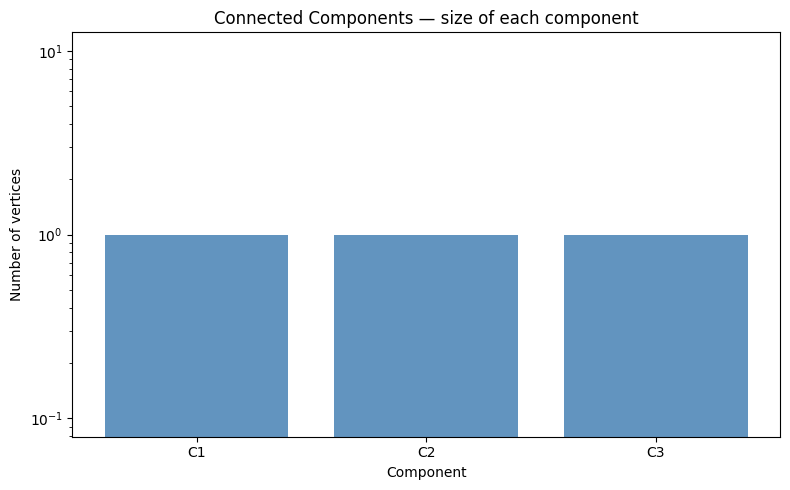

Saved q2a_components.png


In [2]:
q2a = load(f"{BASE}/q2a_components")
if q2a is not None:
    print(q2a.columns.tolist())
    print(q2a.head())
    # Rename columns if needed (Spark saves with original names)
    # Expected cols: id, component (or similar)
    comp_col = [c for c in q2a.columns if 'component' in c.lower()][0]
    sizes = q2a.groupby(comp_col).size().sort_values(ascending=False)
    print(f"Number of components: {len(sizes)}")
    print("Component sizes:", sizes.values[:10])

    fig, ax = plt.subplots(figsize=(8, 5))
    top = sizes.head(10).reset_index()
    top.columns = ['Component', 'Size']
    top['Label'] = [f"C{i+1}" for i in range(len(top))]
    ax.bar(top['Label'], top['Size'], color='steelblue', alpha=0.85)
    ax.set_title('Connected Components — size of each component')
    ax.set_xlabel('Component'); ax.set_ylabel('Number of vertices')
    ax.set_yscale('log')
    plt.tight_layout(); plt.savefig('q2a_components.png', dpi=150); plt.show()
    print("Saved q2a_components.png")

['id', 'v_Zone', 'v_Borough', 'in_degree', 'out_degree', 'total_degree']
   id                   v_Zone      v_Borough  in_degree  out_degree  \
0   1           Newark Airport            EWR      67522        3110   
1   2              Jamaica Bay         Queens         41          19   
2   3  Allerton/Pelham Gardens          Bronx       1764         410   
3   4            Alphabet City      Manhattan      86449       27515   
4   5            Arden Heights  Staten Island        431         346   

   total_degree  
0         70632  
1            60  
2          2174  
3        113964  
4           777  


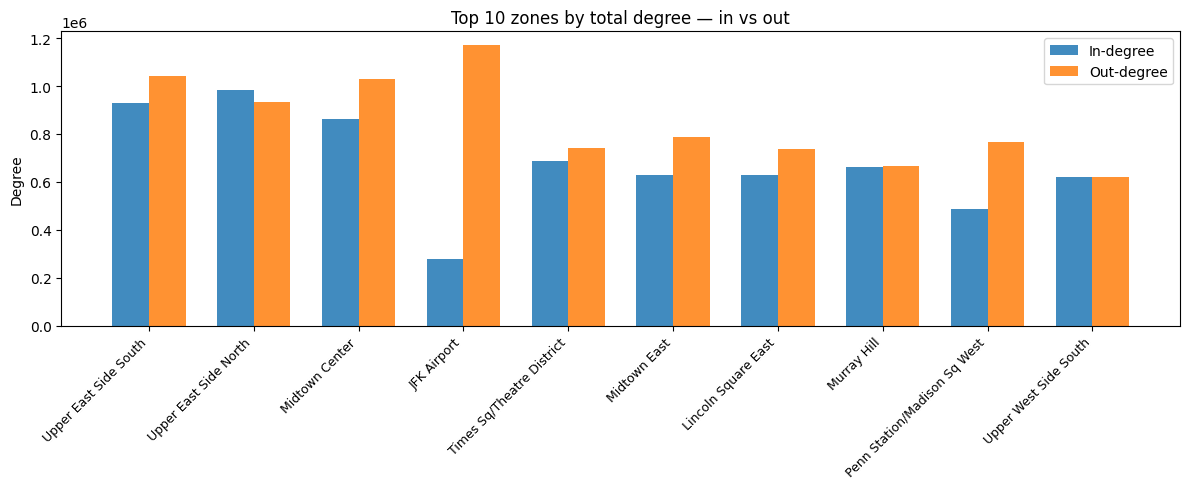

Saved q2b_degrees.png


In [3]:
q2b = load(f"{BASE}/q2b_degrees")
if q2b is not None:
    print(q2b.columns.tolist())
    print(q2b.head())

    zone_col    = next((c for c in q2b.columns if 'zone' in c.lower()), q2b.columns[1])
    borough_col = next((c for c in q2b.columns if 'borough' in c.lower()), q2b.columns[2])
    in_col      = next((c for c in q2b.columns if 'in_degree'   in c.lower()), None)
    out_col     = next((c for c in q2b.columns if 'out_degree'  in c.lower()), None)
    tot_col     = next((c for c in q2b.columns if 'total_degree' in c.lower()), None)

    top10 = q2b.sort_values(tot_col, ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(12, 5))
    x = range(len(top10))
    w = 0.35
    ax.bar([i - w/2 for i in x], top10[in_col],  width=w, label='In-degree',  alpha=0.85)
    ax.bar([i + w/2 for i in x], top10[out_col], width=w, label='Out-degree', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(top10[zone_col], rotation=45, ha='right', fontsize=9)
    ax.set_title('Top 10 zones by total degree — in vs out')
    ax.set_ylabel('Degree'); ax.legend()
    plt.tight_layout(); plt.savefig('q2b_degrees.png', dpi=150); plt.show()
    print("Saved q2b_degrees.png")

['id', 'v_Zone', 'v_Borough', 'hops']
    id                  v_Zone v_Borough  hops
0  132             JFK Airport    Queens     0
1  147                Longwood     Bronx     1
2   19               Bellerose    Queens     1
3   39                Canarsie  Brooklyn     1
4   71  East Flatbush/Farragut  Brooklyn     1


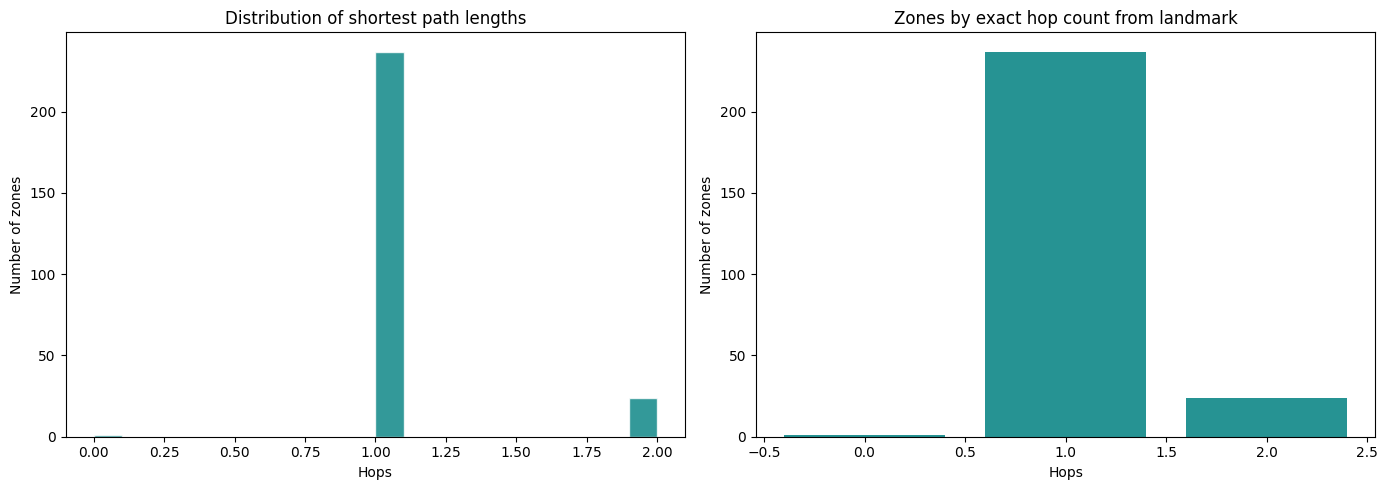

Saved q3_shortest.png


In [4]:
q3 = load(f"{BASE}/q3_shortest")
if q3 is not None:
    print(q3.columns.tolist())
    print(q3.head())

    hop_col = next((c for c in q3.columns if 'hop' in c.lower()), q3.columns[-1])
    q3[hop_col] = pd.to_numeric(q3[hop_col], errors='coerce')
    q3 = q3.dropna(subset=[hop_col])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(q3[hop_col], bins=20, color='teal', alpha=0.8, edgecolor='white')
    axes[0].set_title('Distribution of shortest path lengths')
    axes[0].set_xlabel('Hops'); axes[0].set_ylabel('Number of zones')

    hop_counts = q3[hop_col].value_counts().sort_index()
    axes[1].bar(hop_counts.index.astype(int), hop_counts.values, color='teal', alpha=0.85)
    axes[1].set_title('Zones by exact hop count from landmark')
    axes[1].set_xlabel('Hops'); axes[1].set_ylabel('Number of zones')

    plt.tight_layout(); plt.savefig('q3_shortest.png', dpi=150); plt.show()
    print("Saved q3_shortest.png")

['id', 'v_Zone', 'v_Borough', 'pagerank']
    id             v_Zone  v_Borough  pagerank
0  265                NaN    Unknown  2.035759
1  132        JFK Airport     Queens  1.928746
2   75  East Harlem South  Manhattan  1.724949
3  140    Lenox Hill East  Manhattan  1.603288
4  138  LaGuardia Airport     Queens  1.599217


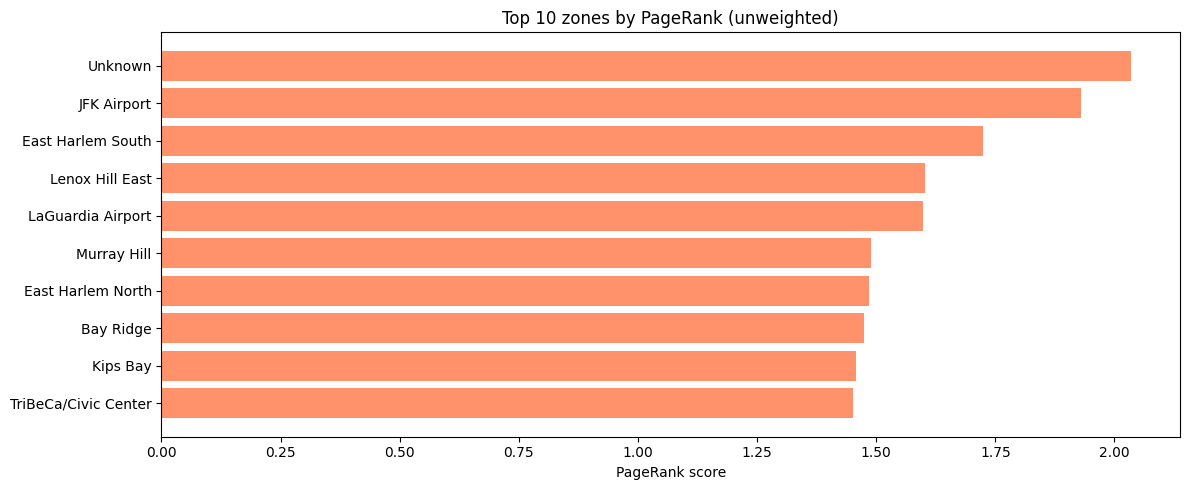

Saved q4a_pagerank.png


In [5]:
q4a = load(f"{BASE}/q4a_pagerank")
if q4a is not None:
    print(q4a.columns.tolist())
    print(q4a.head())

    zone_col = next((c for c in q4a.columns if 'zone' in c.lower()), q4a.columns[1])
    pr_col   = next((c for c in q4a.columns if 'pagerank' in c.lower()), q4a.columns[-1])
    q4a[pr_col]   = pd.to_numeric(q4a[pr_col], errors='coerce')
    q4a[zone_col] = q4a[zone_col].fillna('Unknown').astype(str)
    top10 = q4a.sort_values(pr_col, ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(top10[zone_col].tolist()[::-1], top10[pr_col].tolist()[::-1], color='coral', alpha=0.85)
    ax.set_title('Top 10 zones by PageRank (unweighted)')
    ax.set_xlabel('PageRank score')
    plt.tight_layout(); plt.savefig('q4a_pagerank.png', dpi=150); plt.show()
    print("Saved q4a_pagerank.png")


['id', 'v_Zone', 'v_Borough', 'pagerank']
    id             v_Zone  v_Borough  pagerank
0  265                NaN    Unknown  2.035759
1  132        JFK Airport     Queens  1.928746
2   75  East Harlem South  Manhattan  1.724949
3  140    Lenox Hill East  Manhattan  1.603288
4  138  LaGuardia Airport     Queens  1.599217


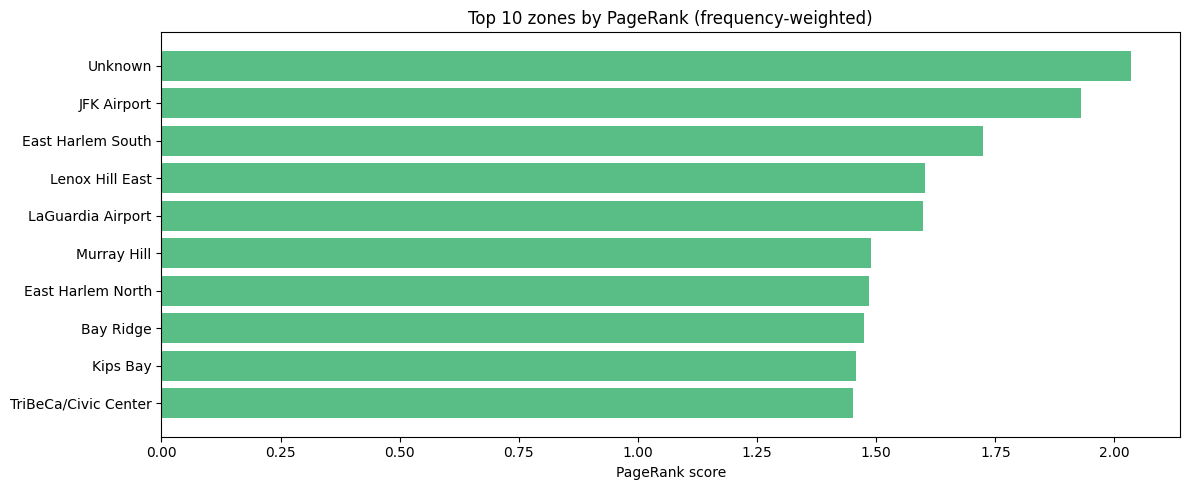

Saved q4b_pagerank_freq.png


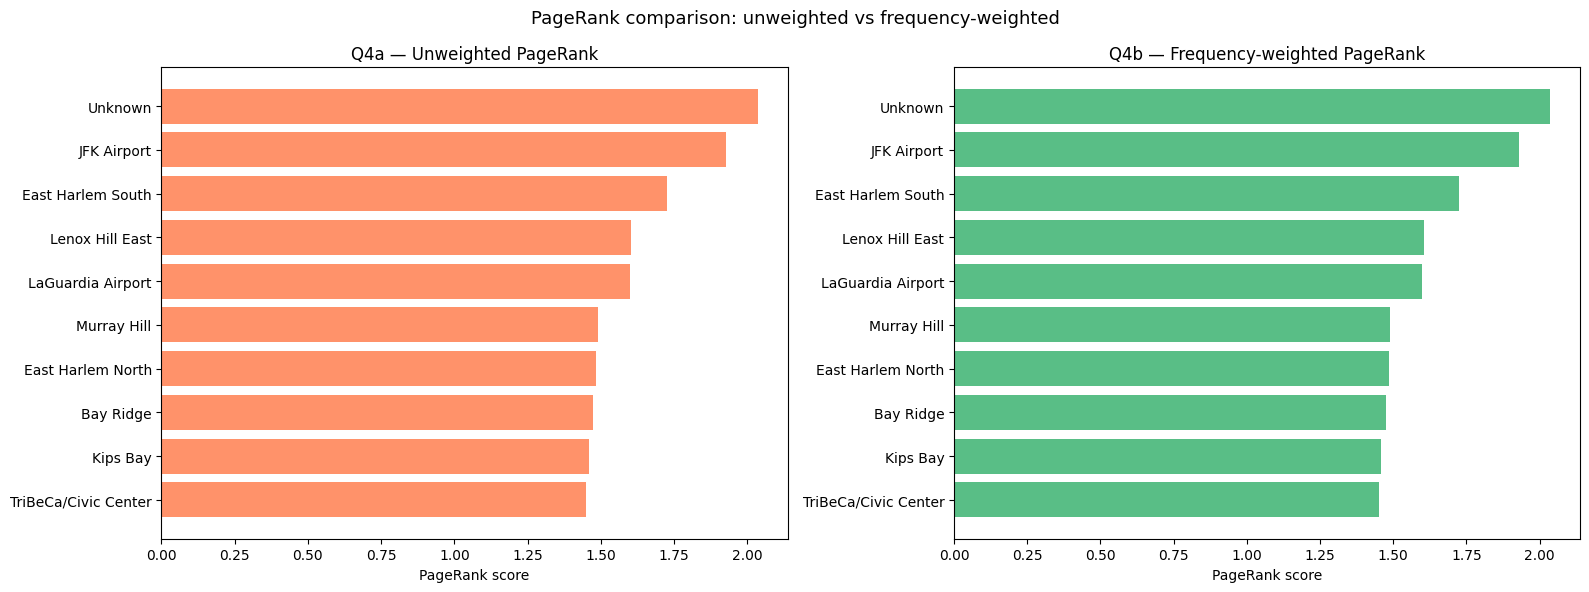

Saved q4_pagerank_comparison.png


In [6]:
q4b = load(f"{BASE}/q4b_pagerank_freq")
if q4b is not None:
    print(q4b.columns.tolist())
    print(q4b.head())

    zone_col = next((c for c in q4b.columns if 'zone' in c.lower()), q4b.columns[1])
    pr_col   = next((c for c in q4b.columns if 'pagerank' in c.lower()), q4b.columns[-1])
    q4b[pr_col]   = pd.to_numeric(q4b[pr_col], errors='coerce')
    q4b[zone_col] = q4b[zone_col].fillna('Unknown').astype(str)
    top10 = q4b.sort_values(pr_col, ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(top10[zone_col].tolist()[::-1], top10[pr_col].tolist()[::-1], color='mediumseagreen', alpha=0.85)
    ax.set_title('Top 10 zones by PageRank (frequency-weighted)')
    ax.set_xlabel('PageRank score')
    plt.tight_layout(); plt.savefig('q4b_pagerank_freq.png', dpi=150); plt.show()
    print("Saved q4b_pagerank_freq.png")

    # Side-by-side comparison if both available
    if q4a is not None:
        zone_col_a = next((c for c in q4a.columns if 'zone' in c.lower()), q4a.columns[1])
        pr_col_a   = next((c for c in q4a.columns if 'pagerank' in c.lower()), q4a.columns[-1])
        top_a = q4a.sort_values(pr_col_a, ascending=False).head(10)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        ax1.barh(top_a[zone_col_a].tolist()[::-1], top_a[pr_col_a].tolist()[::-1], color='coral', alpha=0.85)
        ax1.set_title('Q4a — Unweighted PageRank'); ax1.set_xlabel('PageRank score')
        ax2.barh(top10[zone_col].tolist()[::-1],   top10[pr_col].tolist()[::-1],   color='mediumseagreen', alpha=0.85)
        ax2.set_title('Q4b — Frequency-weighted PageRank'); ax2.set_xlabel('PageRank score')
        plt.suptitle('PageRank comparison: unweighted vs frequency-weighted', fontsize=13)
        plt.tight_layout(); plt.savefig('q4_pagerank_comparison.png', dpi=150); plt.show()
        print("Saved q4_pagerank_comparison.png")


In [7]:
q5 = load(f"{BASE}/q5_communities")
if q5 is None:
    print("Q5 communities data not available — LPA step failed during Spark run.")
    print("Skipping Q5 plot.")
else:
    print(q5.columns.tolist())
    print(q5.head())

    comm_col    = next((c for c in q5.columns if 'community' in c.lower()), q5.columns[-1])
    borough_col = next((c for c in q5.columns if 'borough'   in c.lower()), q5.columns[1])

    top5_ids = q5.groupby(comm_col).size().nlargest(5).index.tolist()
    subset   = q5[q5[comm_col].isin(top5_ids)]
    pivot    = subset.groupby([comm_col, borough_col]).size().unstack(fill_value=0)

    pivot.plot(kind='bar', figsize=(12, 5), colormap='tab10', alpha=0.85)
    plt.title('Borough composition — top 5 communities')
    plt.xlabel('Community'); plt.ylabel('Zones')
    plt.xticks(rotation=0)
    plt.legend(title='Borough', bbox_to_anchor=(1.05, 1))
    plt.tight_layout(); plt.savefig('q5_communities.png', dpi=150); plt.show()
    print("Saved q5_communities.png")

Q5 communities data not available — LPA step failed during Spark run.
Skipping Q5 plot.
